<a href="https://colab.research.google.com/github/MayankGoyal06/Rain-Prediction-System/blob/main/binary_prediction_with_a_rainfall_dataset_soln.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
import tensorflow.keras.backend as K

In [9]:
train_data = pd.read_csv("train.csv", index_col="id")
test_data = pd.read_csv("test.csv", index_col="id")

In [10]:
# from google.colab import files
# uploaded = files.upload()


In [11]:
train_data.shape

(2190, 12)

In [12]:
test_data.shape

(730, 11)

# Exploratory Data Analysis

In [13]:
print("#" * 50)
print(train_data.info())
print("#" * 50)
print(test_data.info())
print("#" * 50)
print("#" * 50)
display(train_data.describe())
print("#" * 50)
display(test_data.describe())

##################################################
<class 'pandas.core.frame.DataFrame'>
Index: 2190 entries, 0 to 2189
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            2190 non-null   int64  
 1   pressure       2190 non-null   float64
 2   maxtemp        2190 non-null   float64
 3   temparature    2190 non-null   float64
 4   mintemp        2190 non-null   float64
 5   dewpoint       2190 non-null   float64
 6   humidity       2190 non-null   float64
 7   cloud          2190 non-null   float64
 8   sunshine       2190 non-null   float64
 9   winddirection  2190 non-null   float64
 10  windspeed      2190 non-null   float64
 11  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(2)
memory usage: 222.4 KB
None
##################################################
<class 'pandas.core.frame.DataFrame'>
Index: 730 entries, 2190 to 2919
Data columns (total 11 columns):
 #   Column       

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,179.948402,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703,0.753425
std,105.203592,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659,0.431116
min,1.000000,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000,0.000000
25%,89.000000,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000,1.000000
50%,178.500000,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,270.000000,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000,1.000000
max,365.000000,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000,1.000000


##################################################


,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,729.000000,730.000000
mean,183.000000,1013.503014,26.372466,23.963288,22.110274,20.460137,82.669863,76.360274,3.664384,103.923182,22.484247
std,105.438271,5.505871,5.672521,5.278098,5.170744,5.391169,7.818714,17.934121,3.639272,81.695458,9.954779
min,1.000000,1000.000000,7.400000,5.900000,4.200000,-0.000000,39.000000,0.000000,0.000000,10.000000,4.500000
25%,92.000000,1008.725000,21.600000,19.825000,17.825000,16.800000,77.250000,69.000000,0.325000,40.000000,14.500000
50%,183.000000,1012.700000,27.800000,25.650000,23.900000,22.300000,82.000000,83.000000,2.200000,70.000000,21.300000
75%,274.000000,1017.600000,31.000000,28.375000,26.400000,25.000000,89.000000,88.000000,6.675000,200.000000,28.400000
max,365.000000,1032.200000,35.800000,31.800000,29.100000,26.700000,98.000000,100.000000,11.800000,300.000000,59.500000


# **Exploratory Data Analysis**

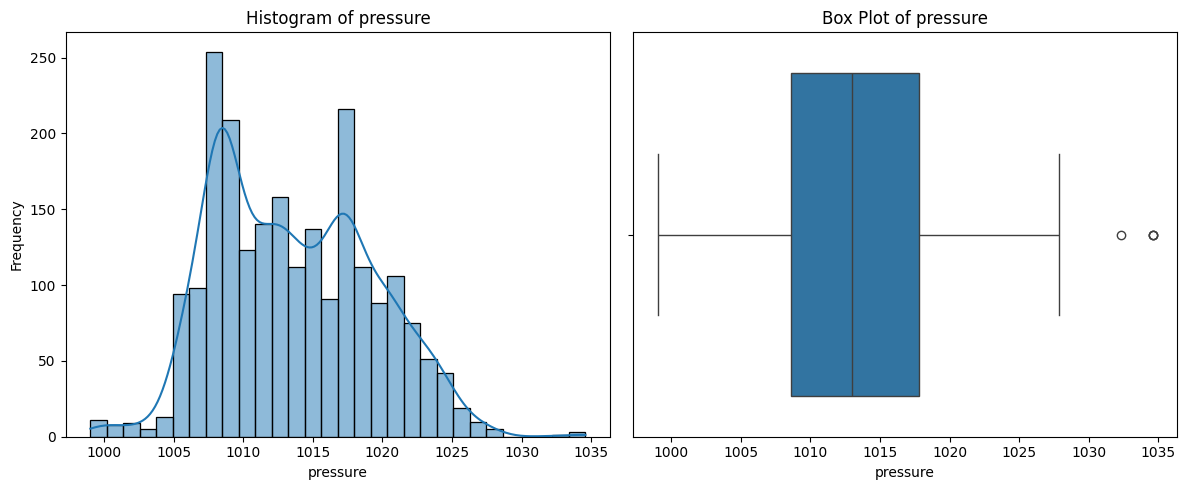


Statistics for pressure:
Skewness: 0.28
Number of Missing Values: 0


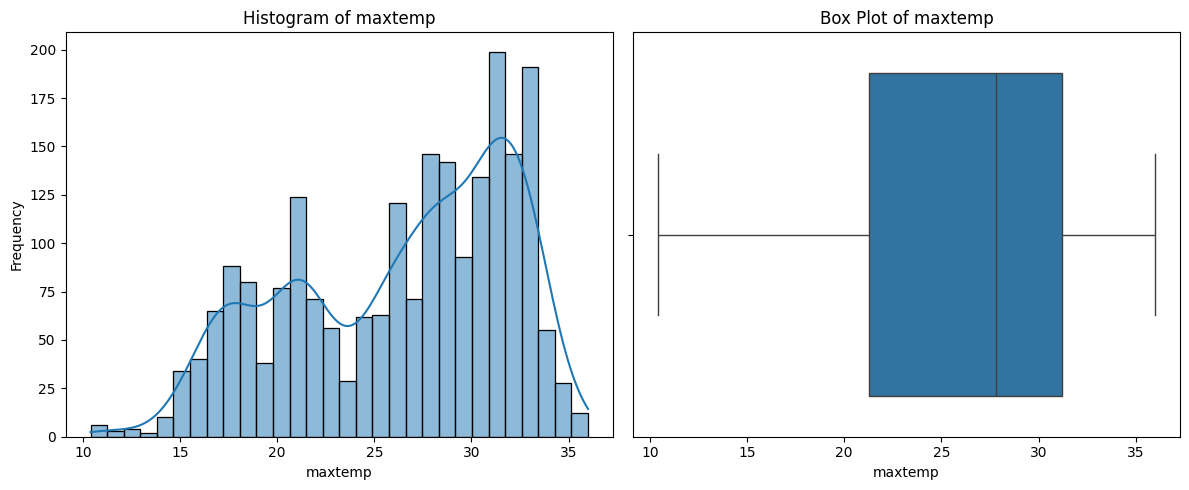


Statistics for maxtemp:
Skewness: -0.49
Number of Missing Values: 0


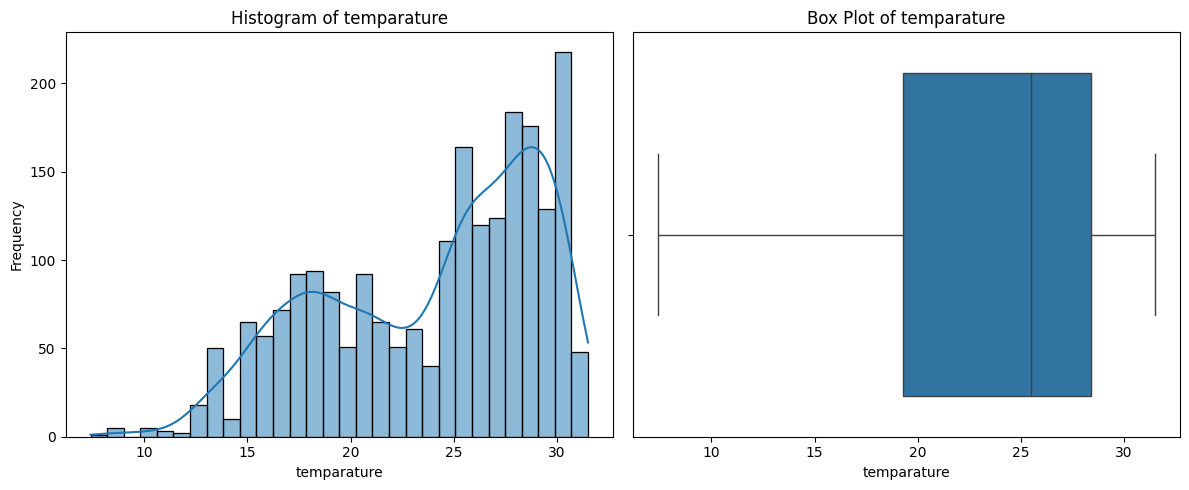


Statistics for temparature:
Skewness: -0.56
Number of Missing Values: 0


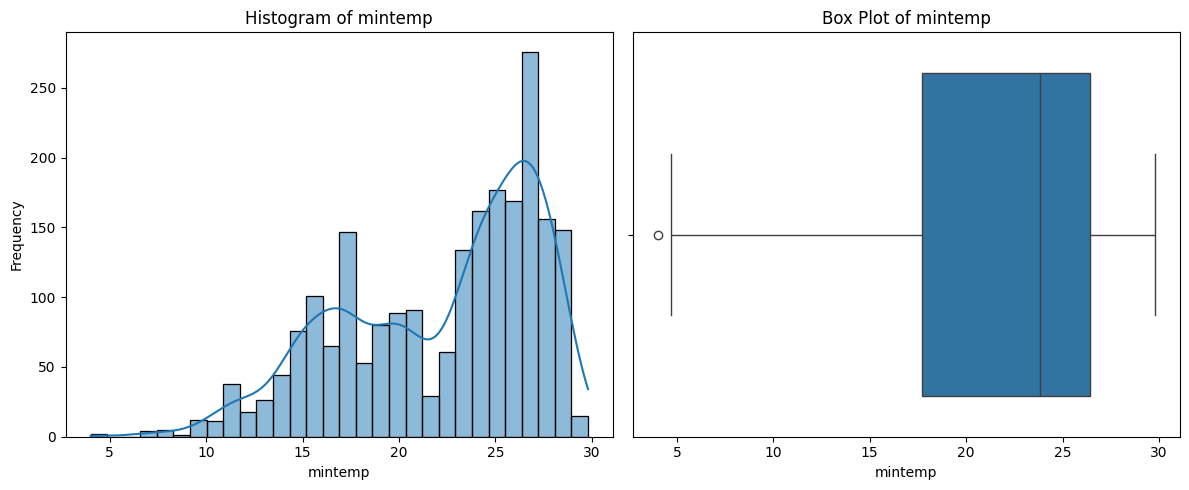


Statistics for mintemp:
Skewness: -0.65
Number of Missing Values: 0


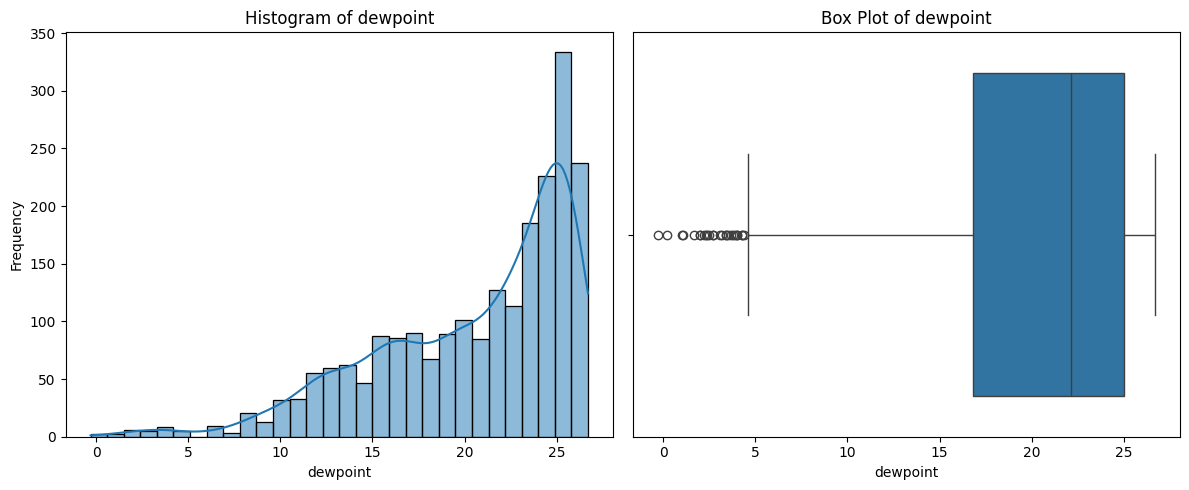


Statistics for dewpoint:
Skewness: -1.00
Number of Missing Values: 0


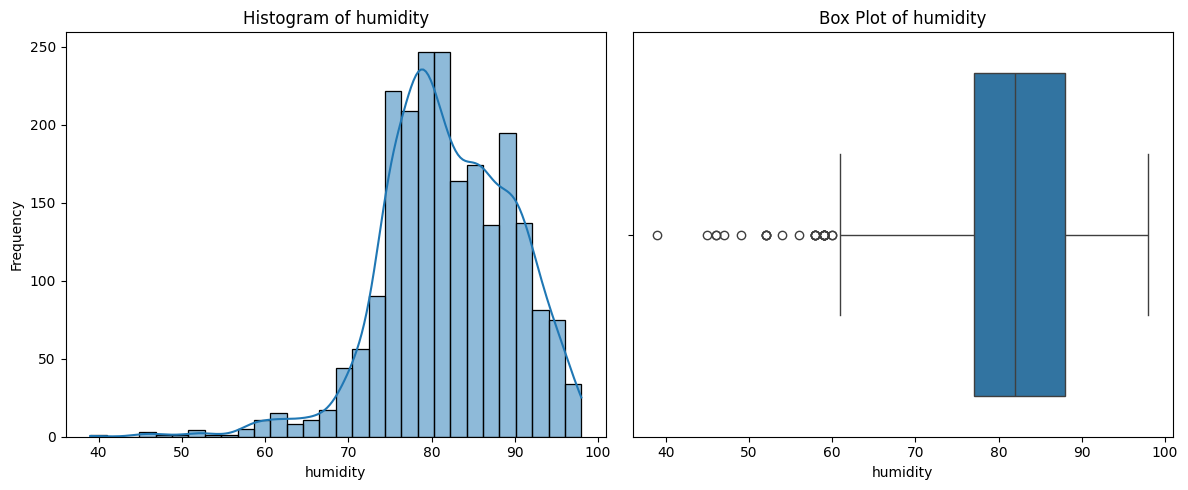


Statistics for humidity:
Skewness: -0.56
Number of Missing Values: 0


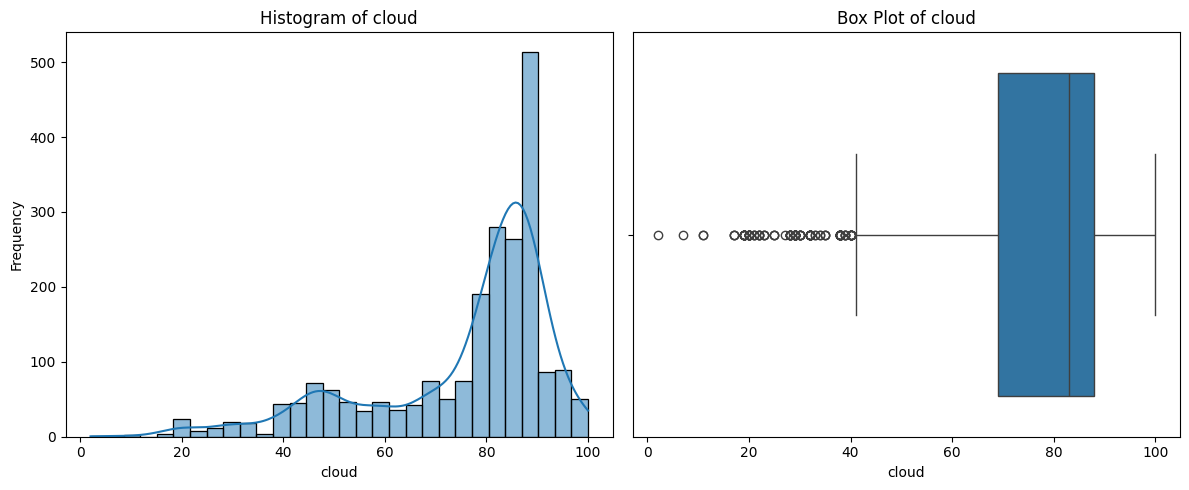


Statistics for cloud:
Skewness: -1.34
Number of Missing Values: 0


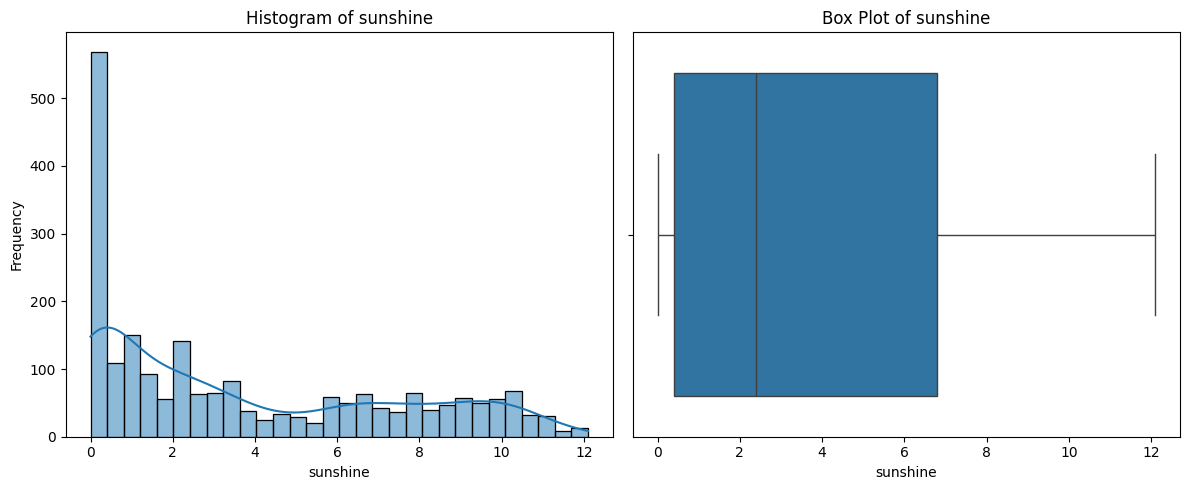


Statistics for sunshine:
Skewness: 0.64
Number of Missing Values: 0


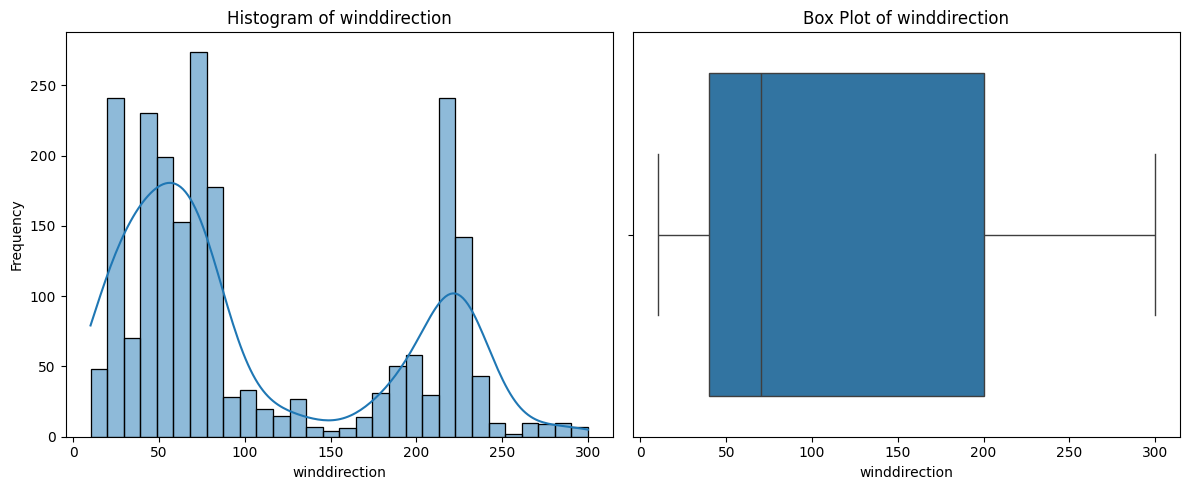


Statistics for winddirection:
Skewness: 0.71
Number of Missing Values: 0


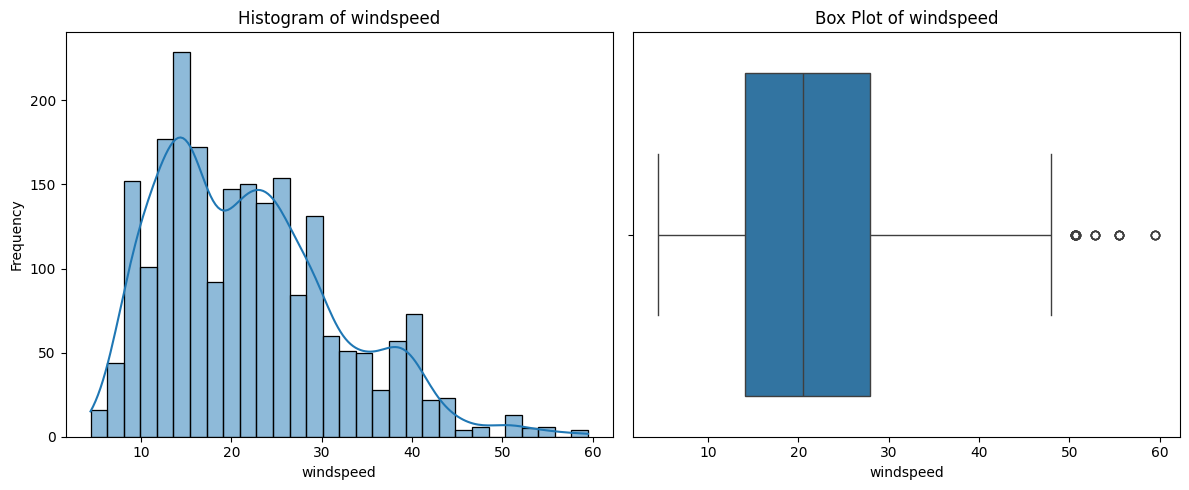


Statistics for windspeed:
Skewness: 0.77
Number of Missing Values: 0


In [14]:
numerical_features = [
    "pressure",
    "maxtemp",
    "temparature",
    "mintemp",
    "dewpoint",
    "humidity",
    "cloud",
    "sunshine",
    "winddirection",
    "windspeed"
]

for feature in numerical_features:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(train_data[feature], kde=True, bins=30)
    plt.title(f"Histogram of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=train_data[feature])
    plt.title(f"Box Plot of {feature}")

    plt.tight_layout()
    plt.show()

    print(f"\nStatistics for {feature}:")
    print(f"Skewness: {train_data[feature].skew():.2f}")
    print(f"Number of Missing Values: {train_data[feature].isnull().sum()}")


Text(0.5, 1.0, 'Cloud and Rainfall Relation')

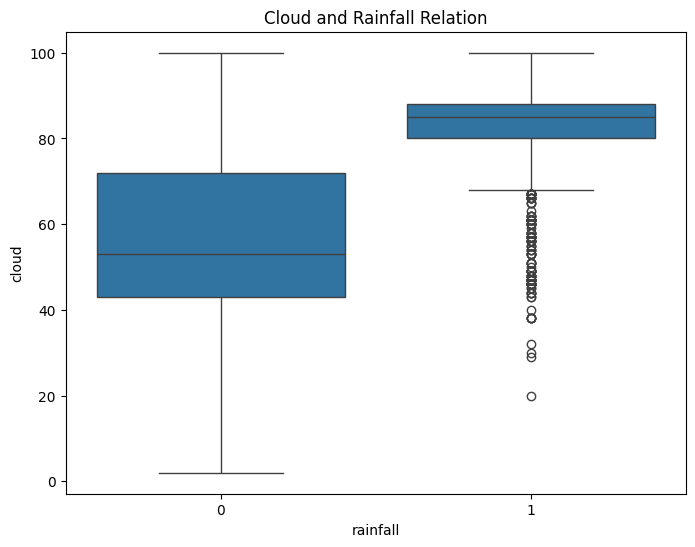

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='rainfall', y='cloud', data=train_data)
plt.title("Cloud and Rainfall Relation")

Text(0.5, 1.0, 'Sunshine and Rainfall Relation')

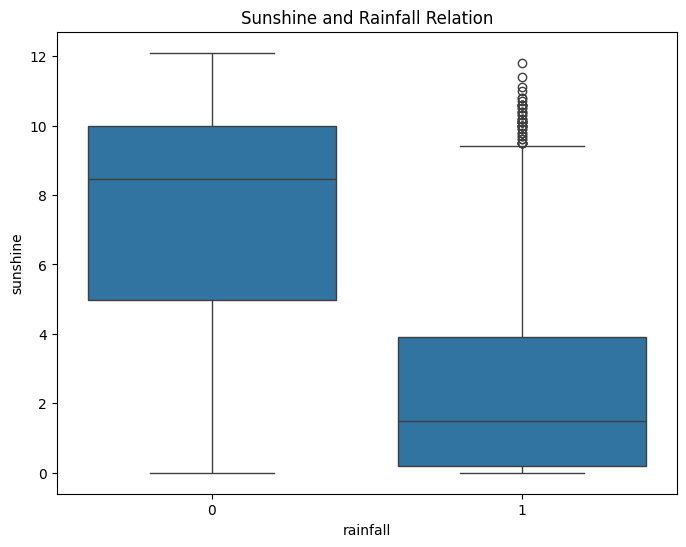

In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='rainfall', y='sunshine', data=train_data)
plt.title("Sunshine and Rainfall Relation")

Text(0.5, 1.0, 'Humidity and Rainfall Relation')

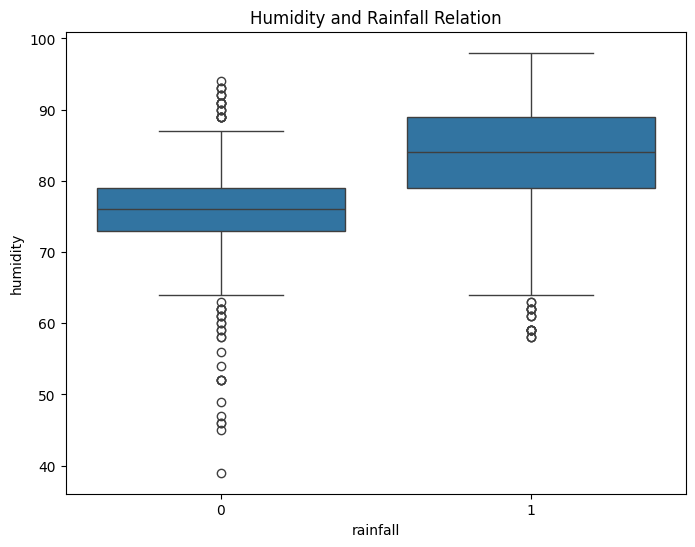

In [17]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='rainfall', y='humidity', data=train_data)
plt.title("Humidity and Rainfall Relation")

Text(0.5, 1.0, 'Temparature and Rainfall Relation')

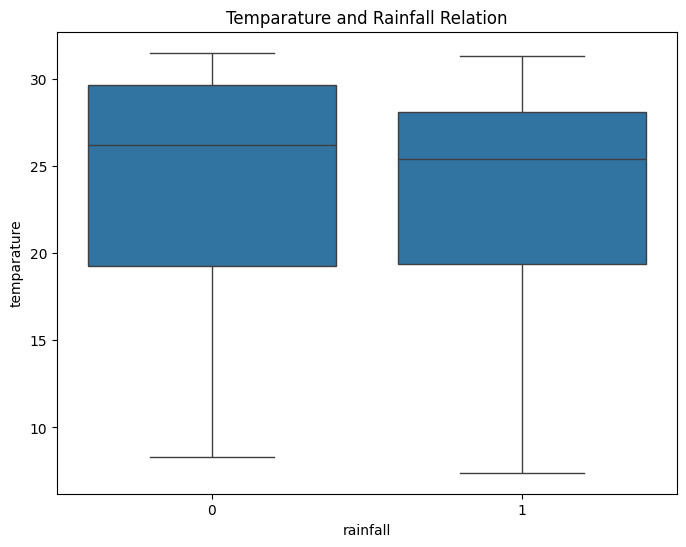

In [18]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='rainfall', y='temparature', data=train_data)
plt.title("Temparature and Rainfall Relation")

Text(0.5, 1.0, 'Mintemp and Rainfall Relation')

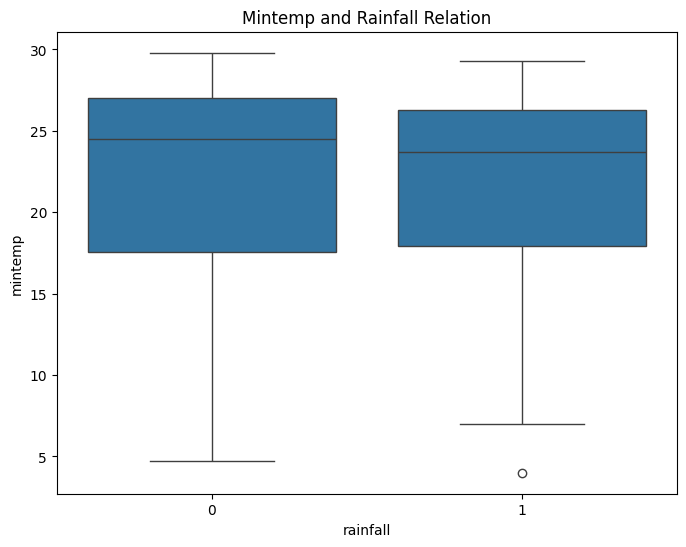

In [19]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='rainfall', y='mintemp', data=train_data)
plt.title("Mintemp and Rainfall Relation")

Text(0.5, 1.0, 'Maxtemp and Rainfall Relation')

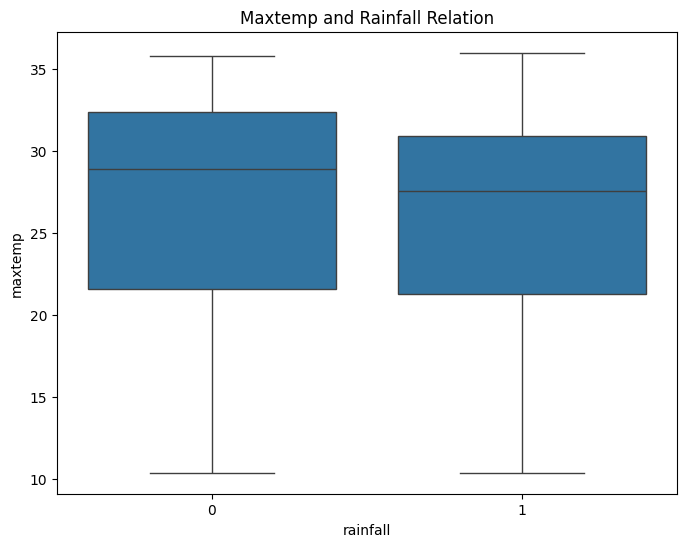

In [20]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='rainfall', y='maxtemp', data=train_data)
plt.title("Maxtemp and Rainfall Relation")

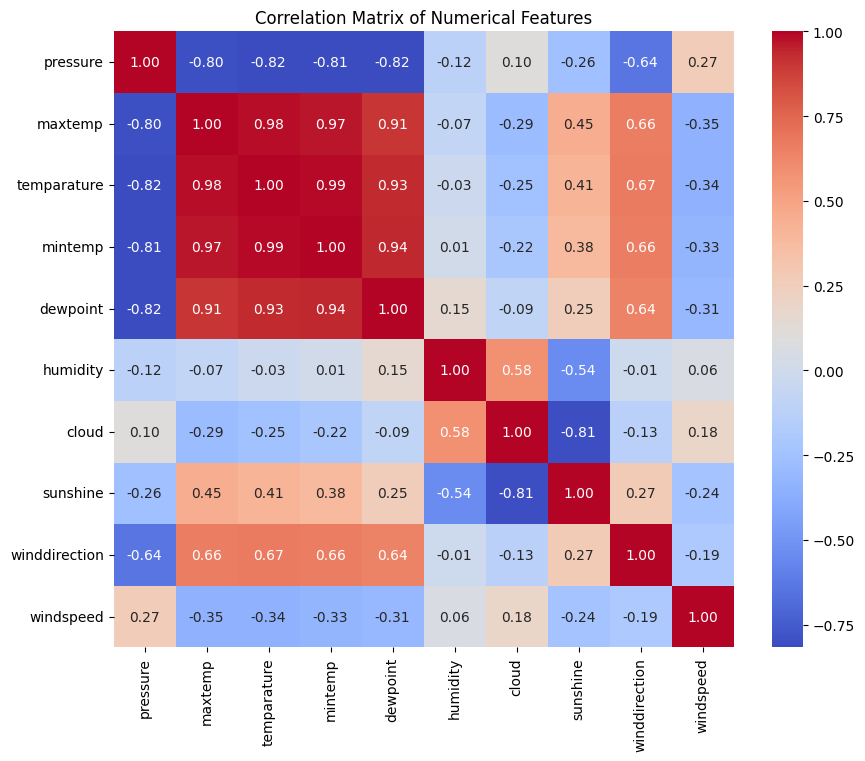

In [21]:
correlation_matrix = train_data[numerical_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# **Feature Engineering**

In [22]:
# Mean Imputation
test_data['winddirection'].fillna(test_data['winddirection'].mean(), inplace=True)

/tmp/ipykernel_5970/2073379307.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['winddirection'].fillna(test_data['winddirection'].mean(), inplace=True)


In [23]:
train_data["temp diff"] = ((train_data["mintemp"] + train_data["maxtemp"])/2) - train_data["temparature"]
test_data["temp diff"] = ((test_data["mintemp"] + test_data["maxtemp"])/2) - test_data["temparature"]
train_data['humidity_temp'] = train_data['humidity'] * train_data['temparature']
train_data['wind_effect'] = train_data['windspeed'] * np.cos(train_data['winddirection'])
test_data['humidity_temp'] = test_data['humidity'] * test_data['temparature']
test_data['wind_effect'] = test_data['windspeed'] * np.cos(test_data['winddirection'])
train_data['dew_point_diff'] = train_data['temparature'] - train_data['dewpoint']
test_data['dew_point_diff'] = test_data['temparature'] - test_data['dewpoint']
train_data['ema_temp'] = train_data['temparature'].ewm(span=5, adjust=False).mean()
test_data['ema_temp'] = test_data['temparature'].ewm(span=5, adjust=False).mean()
train_data['wind_pressure_interaction'] = train_data['windspeed'] * train_data['pressure']
test_data['wind_pressure_interaction'] = test_data['windspeed'] * test_data['pressure']
train_data['humidity_tempdiv'] = train_data['humidity'] / train_data['temparature']
test_data['humidity_tempdiv'] = test_data['humidity'] / test_data['temparature']

In [24]:
train_data.drop(["mintemp", "maxtemp", "temparature"], axis = 1, inplace = True)
test_data.drop(["mintemp", "maxtemp", "temparature"], axis = 1, inplace = True)

In [25]:
train_data.head()

,day,pressure,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,temp diff,humidity_temp,wind_effect,dew_point_diff,ema_temp,wind_pressure_interaction,humidity_tempdiv
id,,,,,,,,,,,,,,,,
0,1,1017.4,19.4,87.0,88.0,1.1,60.0,17.2,1,-0.05,1792.2,-16.381503,1.2,20.600000,17499.28,4.223301
1,2,1019.5,15.4,95.0,91.0,0.0,50.0,21.9,1,-0.90,1605.5,21.132756,1.5,19.366667,22327.05,5.621302
2,3,1024.1,9.3,75.0,47.0,8.3,70.0,18.1,1,0.90,1207.5,11.463078,6.8,18.277778,18536.21,4.658385
3,4,1013.4,16.8,95.0,95.0,0.0,60.0,35.6,1,-0.30,1691.0,-33.905902,1.0,18.118519,36077.04,5.337079
4,5,1021.8,9.6,52.0,45.0,3.6,40.0,24.8,0,-0.15,956.8,-16.540064,8.8,18.212346,25340.64,2.826087


In [26]:
test_data.head()

,day,pressure,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,temp diff,humidity_temp,wind_effect,dew_point_diff,ema_temp,wind_pressure_interaction,humidity_tempdiv
id,,,,,,,,,,,,,,,
2190,1,1019.5,14.9,96.0,99.0,0.0,50.0,24.3,-0.70,1516.8,23.448674,0.9,15.800000,24773.85,6.075949
2191,2,1016.5,15.1,97.0,99.0,0.0,50.0,35.3,0.15,1600.5,34.063301,1.4,16.033333,35882.45,5.878788
2192,3,1023.9,8.9,86.0,96.0,0.0,40.0,16.9,-0.10,894.4,-11.271253,1.5,14.155556,17303.91,8.269231
2193,4,1022.9,9.5,75.0,45.0,7.1,20.0,50.6,0.60,1297.5,20.648952,7.8,15.203704,51758.74,4.335260
2194,5,1022.2,4.3,68.0,49.0,9.2,20.0,19.4,-2.55,938.4,7.916792,9.5,14.735802,19830.68,4.927536


In [27]:
X = train_data.drop(columns=['rainfall'])
y = train_data['rainfall']

scaler = StandardScaler()

X = scaler.fit_transform(X)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Selection

In [28]:
# param_grid = {
#     'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
#     'penalty': ['l1', 'l2'],
#     'solver': ['liblinear', 'saga'],
#     'max_iter': [100, 200, 500, 1000]
# }

best_params = {'C': 0.001, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}

log_reg = LogisticRegression(**best_params, random_state = 42)

log_reg.fit(X_train, y_train)

y_pred_proba = log_reg.predict_proba(X_valid)[:, 1]

roc_auc = roc_auc_score(y_valid, y_pred_proba)
print("Test ROC AUC Score:", roc_auc)

Test ROC AUC Score: 0.8716577540106952


In [29]:
# param_grid = {
#     'n_estimators': [1200, 1250, 1300],
#     'max_depth': [3, 5, 10, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2']
# }
best_params = {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 400}

rf = RandomForestClassifier(**best_params, random_state=42)

# grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
#                            cv=3, n_jobs=-1, verbose=1, scoring='roc_auc')

rf.fit(X_train, y_train)

y_prob = rf.predict_proba(X_valid)[:, 1]

auc_score = roc_auc_score(y_valid, y_prob)
print(f"Test ROC-AUC Score: {auc_score:.4f}")

Test ROC-AUC Score: 0.8722


In [30]:
# param_grid = {
#     'n_neighbors': [3, 5, 7, 9, 11],
#     'weights': ['uniform', 'distance'],
#     'metric': ['euclidean', 'manhattan', 'minkowski'],
#     'p': [1, 2]
# }

best_params = {
    'n_neighbors': 7,
    'weights': 'distance',
    'metric': 'minkowski',
    'p': 2
}

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(**best_params)

# grid_search = GridSearchCV(estimator=KNeighborsClassifier(),
#                            param_grid=param_grid,
#                            cv=3, n_jobs=-1, verbose=1, scoring='roc_auc')

knn_model.fit(X_train, y_train)
y_prob = knn_model.predict_proba(X_valid)[:, 1]

auc_score = roc_auc_score(y_valid, y_prob)
print(f"Test ROC-AUC Score: {auc_score:.4f}")

Test ROC-AUC Score: 0.8509


In [31]:
# param_grid = {
#     'n_estimators': [50, 100, 150, 200],
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'max_depth': [3, 5, 7],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'subsample': [0.8, 1.0]
# }

best_params = {
    'n_estimators': 150,
    'learning_rate': 0.05,
    'max_depth': 3,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'subsample': 0.8
}

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(**best_params, random_state=42)

# grid_search = GridSearchCV(estimator=GradientBoostingClassifier(random_state=42),
#                            param_grid=param_grid,
#                            cv=3, n_jobs=-1, verbose=1, scoring='roc_auc')

gb_model.fit(X_train, y_train)

y_prob = gb_model.predict_proba(X_valid)[:, 1]

auc_score = roc_auc_score(y_valid, y_prob)
print(f"Test ROC-AUC Score: {auc_score:.4f}")

Test ROC-AUC Score: 0.8650


In [32]:
model = Sequential([
    Input(shape=(15,)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,993 (35.13 KB)

 Trainable params: 8,993 (35.13 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=40,
    batch_size=256,
    verbose=1
)

Epoch 1/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.7563 - auc: 0.6175 - loss: 0.6753 - val_accuracy: 0.7603 - val_auc: 0.7860 - val_loss: 0.6541
Epoch 2/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7922 - auc: 0.7810 - loss: 0.6294 - val_accuracy: 0.7740 - val_auc: 0.8082 - val_loss: 0.6011
Epoch 3/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8071 - auc: 0.8205 - loss: 0.5609 - val_accuracy: 0.8105 - val_auc: 0.8313 - val_loss: 0.5200
Epoch 4/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8345 - auc: 0.8534 - loss: 0.4641 - val_accuracy: 0.8288 - val_auc: 0.8460 - val_loss: 0.4312
Epoch 5/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8579 - auc: 0.8821 - loss: 0.3688 - val_accuracy: 0.8447 - val_auc: 0.8571 - val_loss: 0.3877
Epoch 6/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8664 - auc: 0.8923 - loss: 0.3328 - val_accuracy: 0.8470 - val_auc: 0.8599 - val_loss: 0.4021
Epoch 7/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accurac

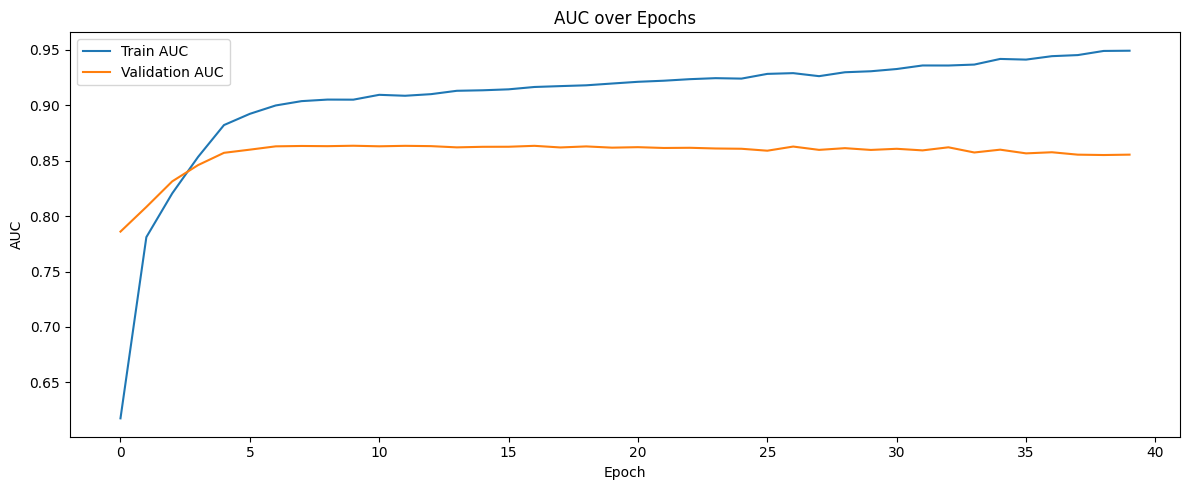

In [34]:
plt.figure(figsize=(12, 5))

# MAE
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('AUC over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

# Model Evaluation and Final Prediction

In [35]:
test_data = scaler.transform(test_data)
y_final = model.predict(test_data).flatten()

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [36]:
custom_index = np.arange(2190, 2920)

df_predictions = pd.DataFrame({'rainfall': y_final}, index=custom_index)

df_predictions.reset_index(drop=False, inplace=True)

df_predictions.rename(columns={'index': 'id'}, inplace=True)

In [37]:
df_predictions.to_csv("Predictions.csv", index = False)

In [38]:
df_predictions

,id,rainfall
0,2190,0.998085
1,2191,0.999309
2,2192,0.989693
3,2193,0.090492
4,2194,0.008859
...,...,...
725,2915,0.998480
726,2916,0.918675
727,2917,0.995592
728,2918,0.980583


In [39]:
# !ls

In [40]:
# from google.colab import files
# files.download("Predictions.csv")